# Step 8: Trained usage classifier

Every step so far has used FashionCLIP's weights completely frozen -- we've only done averaging and cosine similarity on top of its outputs. This notebook is different: we train a small classifier of our own, on top of the frozen embeddings, to predict an item's `usage` category (Casual, Formal, Party, Sports, Ethnic) from real labels in the dataset. This is the one place in the project with actual gradient-based training: a train/val/test split, a loss function, an optimizer, multiple epochs, and a watch for overfitting.

## Build the dataset: X (embeddings) and y (usage labels)

We reuse the cached item embeddings from notebook 03 -- no need to touch FashionCLIP at all in this notebook, since the embeddings already capture everything about each image that our classifier will use. We join them against `styles.csv`'s `usage` column, and keep only the 5 categories named in the project scope: `Casual`, `Formal`, `Party`, `Sports`, `Ethnic`. Everything else (missing labels, and off-scope categories like `Travel` or the single `Home` example) gets dropped.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

item_embeddings = np.load(Path("../data/embeddings/item_embeddings.npy"))
item_ids = np.load(Path("../data/embeddings/item_ids.npy"))

dataset_root = Path.home() / ".cache/kagglehub/datasets/paramaggarwal/fashion-product-images-small/versions/1"
styles_df = pd.read_csv(dataset_root / "styles.csv", on_bad_lines="skip").set_index("id")

KEEP_CLASSES = ["Casual", "Formal", "Party", "Sports", "Ethnic"]

# Look up each embedded item's usage label, in the same row order as item_embeddings/item_ids
usage_labels = styles_df.reindex(item_ids)["usage"]
keep_mask = usage_labels.isin(KEEP_CLASSES).to_numpy()

X = item_embeddings[keep_mask]
y = usage_labels[keep_mask].to_numpy()

print("X shape:", X.shape)
print("y counts:\n", pd.Series(y).value_counts())

X shape: (44008, 512)
y counts:
 Casual    34401
Sports     4025
Ethnic     3208
Formal     2345
Party        29
Name: count, dtype: int64


## Encode labels as integers

Neural networks work with numbers, not strings. `LabelEncoder` assigns each unique class name an integer (alphabetically, so `Casual` -> 0, `Ethnic` -> 1, etc.) -- we'll map back to names later when reading results.

In [2]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

for name, encoded in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"{encoded}: {name}")

0: Casual
1: Ethnic
2: Formal
3: Party
4: Sports


## Split into train / validation / test

Three separate sets, each with a specific job:
- **Train**: what the model actually learns from -- its weights get updated based on this data.
- **Validation**: checked after every epoch during training, *without* updating weights on it. This is how we watch for overfitting (the model doing great on train but not generalizing) and decide when to stop.
- **Test**: touched exactly once, at the very end, to report final honest performance. If we tuned decisions based on test set results, we'd be fooling ourselves about how well the model generalizes.

We split 70/15/15. Since `Party` has only 29 examples total, a plain random split could easily starve one of these sets of Party examples entirely by chance. `stratify=y_encoded` tells `train_test_split` to preserve each class's proportion in every split -- so all three sets get a representative (if still tiny, for Party) slice.

In [3]:
from sklearn.model_selection import train_test_split

# First peel off 30% as a combined val+test pool, then split that pool in half
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.30, stratify=y_encoded, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)

Train: (30805, 512)  Val: (6601, 512)  Test: (6602, 512)


## Standardize the features

Neural networks generally train faster and more stably when input features are on a similar scale (roughly zero mean, unit variance) -- large or wildly-varying raw values can make gradient descent noisy. `StandardScaler` does this: for each of the 512 dimensions, subtract the mean and divide by the standard deviation.

The important detail: we **fit** the scaler (compute the mean/std) only on the *training* set, then use those same numbers to transform train, val, and test. If we fit on the full dataset first and split afterward, statistics from val/test would leak into how the training data gets scaled -- a subtle form of the model "seeing" test data early, which would make our evaluation dishonestly optimistic.

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit AND transform on train
X_val_scaled = scaler.transform(X_val)           # transform only -- reuse train's stats
X_test_scaled = scaler.transform(X_test)         # transform only -- reuse train's stats

print("Train mean (should be ~0):", X_train_scaled.mean().round(4))
print("Train std (should be ~1):", X_train_scaled.std().round(4))

Train mean (should be ~0): 0.0
Train std (should be ~1): 1.0


## Handle class imbalance with class weights

With Casual at ~34k examples and Party at ~20 (after splitting), a model trained normally could get high accuracy by essentially never predicting Party at all and still be "right" almost every time -- accuracy alone can't tell the difference between a good model and one that just learned to ignore rare classes.

`compute_class_weight("balanced", ...)` assigns each class a weight inversely proportional to its frequency -- rare classes (Party) get a large weight, common ones (Casual) get a small weight. We pass these into the loss function next, so a mistake on a Party example is penalized much more heavily than a mistake on a Casual one, giving the model an actual incentive to learn the rare classes instead of ignoring them.

In [5]:
from sklearn.utils.class_weight import compute_class_weight
import torch

class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)

for name, weight in zip(label_encoder.classes_, class_weights):
    print(f"{name:<10} weight={weight:.3f}")

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

Casual     weight=0.256
Ethnic     weight=2.743
Formal     weight=3.752
Party      weight=308.050
Sports     weight=2.187


## Set up tensors and mini-batches

We train with **mini-batch gradient descent**: instead of computing the loss on all ~30k training examples at once (slow, memory-heavy) or one example at a time (noisy, slow to converge), we process small random batches (256 examples) at a time, updating the model's weights after each batch. `TensorDataset` + `DataLoader` handle the batching and shuffling for us -- `shuffle=True` on the training loader means each epoch sees the data in a different random order, which helps the model avoid learning spurious patterns tied to data ordering.

We keep validation and test as single unshuffled batches, since we're only ever running them forward (no training), and their much smaller and fixed size makes batching unnecessary.

In [6]:
from torch.utils.data import TensorDataset, DataLoader

device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

def to_tensor(X, y):
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

X_train_t, y_train_t = to_tensor(X_train_scaled, y_train)
X_val_t, y_val_t = to_tensor(X_val_scaled, y_val)
X_test_t, y_test_t = to_tensor(X_test_scaled, y_test)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=256, shuffle=True)

X_val_t, y_val_t = X_val_t.to(device), y_val_t.to(device)
X_test_t, y_test_t = X_test_t.to(device), y_test_t.to(device)

print("Batches per epoch:", len(train_loader))

Using device: mps


Batches per epoch: 121


## Define the classifier

A small feed-forward network: 512 (embedding size) -> 128 (hidden layer) -> 5 (one output per class). `ReLU` is the non-linearity between layers -- without it, stacking linear layers would collapse into one big linear layer, unable to learn anything a single layer couldn't. `Dropout` randomly zeroes out 30% of the hidden layer's values during training only, which prevents the network from over-relying on any single feature -- a regularization technique that helps fight overfitting.

The output layer produces 5 raw numbers (**logits**), one per class, with no activation function applied -- the loss function we'll use next expects raw logits and applies the necessary math (softmax) internally.

In [7]:
import torch.nn as nn

class UsageClassifier(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=128, num_classes=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.net(x)

num_classes = len(label_encoder.classes_)
model = UsageClassifier(input_dim=512, hidden_dim=128, num_classes=num_classes).to(device)
print(model)

UsageClassifier(
  (net): Sequential(
    (0): Linear(in_features=512, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=5, bias=True)
  )
)


## Loss function and optimizer

**Cross-entropy loss** is the standard choice for multi-class classification: it compares the model's predicted probability distribution over the 5 classes against the true label, and penalizes confident-but-wrong predictions much more heavily than uncertain ones. We pass in `class_weights_tensor` from earlier so mistakes on rare classes count for more.

**Adam** is the optimizer -- the algorithm that actually updates the model's weights based on the gradients computed from the loss. It adapts the effective learning rate per-parameter as training progresses, which generally makes it converge faster and more reliably than plain gradient descent with a single fixed learning rate.

In [8]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## The training loop

One **epoch** = one full pass through the training data. For each epoch:
1. **Training phase** (`model.train()`): for each mini-batch, run a forward pass (compute predictions), compute the loss, run `loss.backward()` (backpropagation -- computes how much each weight contributed to the error), then `optimizer.step()` (Adam nudges every weight slightly to reduce that error).
2. **Validation phase** (`model.eval()`, `torch.no_grad()`): run the *whole* validation set through the model with no weight updates and no gradient tracking (cheaper, since we're not backpropagating), just to check how it's doing on data it didn't train on.

**Early stopping**: after each epoch, if validation accuracy improved, we save a copy of the model's weights as the new "best" version. If it hasn't improved for `PATIENCE` epochs in a row, we stop -- this is exactly the "watch train vs. validation accuracy... stop early if validation stalls" step from the project scope. Without this, the model would keep fitting the training set ever more closely while actually getting *worse* at generalizing -- textbook overfitting.

In [9]:
MAX_EPOCHS = 50
PATIENCE = 5

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = -1.0
best_state = None
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(dim=1) == yb).sum().item()
        total += xb.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_t)
        val_loss = criterion(val_logits, y_val_t).item()
        val_acc = (val_logits.argmax(dim=1) == y_val_t).float().mean().item()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:2d} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
          f"| val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print(f"\nStopping early -- no val improvement for {PATIENCE} epochs.")
            break

model.load_state_dict(best_state)
print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Epoch  1 | train_loss=0.5498 train_acc=0.7588 | val_loss=0.2799 val_acc=0.8061


Epoch  2 | train_loss=0.2920 train_acc=0.8128 | val_loss=0.2279 val_acc=0.8387


Epoch  3 | train_loss=0.2474 train_acc=0.8391 | val_loss=0.2659 val_acc=0.8361


Epoch  4 | train_loss=0.2324 train_acc=0.8399 | val_loss=0.2659 val_acc=0.8465


Epoch  5 | train_loss=0.2041 train_acc=0.8481 | val_loss=0.3110 val_acc=0.8574


...

Epoch 28 | train_loss=0.0813 train_acc=0.9312 | val_loss=0.7922 val_acc=0.9038


Epoch 29 | train_loss=0.0791 train_acc=0.9328 | val_loss=0.8484 val_acc=0.9015


Epoch 30 | train_loss=0.0724 train_acc=0.9381 | val_loss=0.6668 val_acc=0.9049


Epoch 31 | train_loss=0.0738 train_acc=0.9385 | val_loss=0.7922 val_acc=0.9050


Epoch 32 | train_loss=0.0678 train_acc=0.9414 | val_loss=0.8668 val_acc=0.9061

Stopping early -- no val improvement for 5 epochs.

Best validation accuracy: 0.9082


## Visualize training: loss and accuracy curves

If training worked normally, you should see both loss curves fall together early on, then train loss keep dropping while val loss flattens or starts creeping back up -- that inflection point is overfitting starting, and it's exactly what early stopping is watching for.

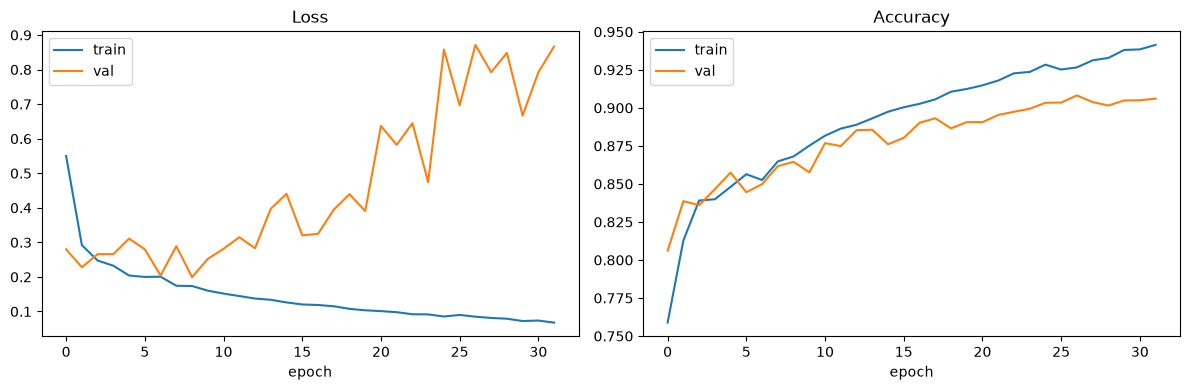

In [10]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_loss"], label="train")
ax1.plot(history["val_loss"], label="val")
ax1.set_title("Loss")
ax1.set_xlabel("epoch")
ax1.legend()

ax2.plot(history["train_acc"], label="train")
ax2.plot(history["val_acc"], label="val")
ax2.set_title("Accuracy")
ax2.set_xlabel("epoch")
ax2.legend()

plt.tight_layout()
plt.show()

## Final evaluation on the test set

This is the one and only time we touch the test set. `classification_report` gives, per class:
- **Precision**: of everything the model *predicted* as this class, what fraction actually was?
- **Recall**: of everything that *actually is* this class, what fraction did the model catch?
- **F1**: the harmonic mean of precision and recall, a single number balancing both.
- **Support**: how many real examples of that class were in the test set -- watch this column for Party, since a tiny support number means its precision/recall will be noisy almost by definition (a single flipped prediction swings the score a lot).

This is also why we can't just look at overall accuracy: with Casual so dominant, a model could score high accuracy while being nearly useless at recognizing Party or Formal.

In [11]:
from sklearn.metrics import classification_report

model.eval()
with torch.no_grad():
    test_logits = model(X_test_t)
    test_preds = test_logits.argmax(dim=1).cpu().numpy()

test_acc = (test_preds == y_test).mean()
print(f"Test accuracy: {test_acc:.4f}\n")
print(classification_report(y_test, test_preds, target_names=label_encoder.classes_))

Test accuracy: 0.9090

              precision    recall  f1-score   support

      Casual       0.97      0.91      0.94      5161
      Ethnic       0.86      0.96      0.91       481
      Formal       0.70      0.90      0.79       352
       Party       0.17      0.25      0.20         4
      Sports       0.67      0.87      0.76       604

    accuracy                           0.91      6602
   macro avg       0.68      0.78      0.72      6602
weighted avg       0.92      0.91      0.91      6602



## Confusion matrix

Each row is a true class, each column is a predicted class -- cell `(i, j)` counts how many examples of true class `i` got predicted as class `j`. A perfect classifier would have all its mass on the diagonal (predicted = actual). Off-diagonal cells show *which* classes the model actually confuses, e.g. Ethnic items misclassified as Casual would show up as a bright cell off the diagonal in that row.

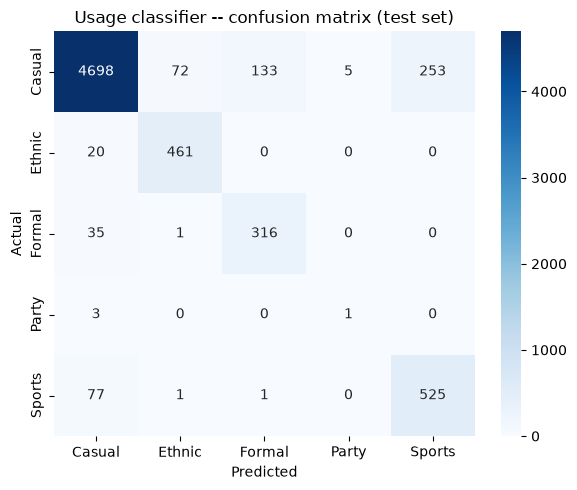

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Usage classifier -- confusion matrix (test set)")
plt.tight_layout()
plt.show()

## Save the trained classifier

We save the model's weights, plus everything needed to use it at inference time later: the `StandardScaler`'s fitted mean/std (new data must be scaled the same way), and the label encoder's class order (to map predicted integers back to class names).

In [13]:
checkpoint = {
    "model_state_dict": model.state_dict(),
    "input_dim": 512,
    "hidden_dim": 128,
    "num_classes": num_classes,
    "class_names": label_encoder.classes_.tolist(),
    "scaler_mean": scaler.mean_,
    "scaler_scale": scaler.scale_,
}

output_path = Path("../data/embeddings/usage_classifier.pt")
torch.save(checkpoint, output_path)

print(f"Saved classifier to {output_path}")

Saved classifier to ../data/embeddings/usage_classifier.pt
